In [44]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
N, K = 1000, 15
m = 2
eps_scale = .10


r = 0.1
p = 0.4
q = 1 - p - r

edges, dst_edges, community_labels, A = graph_info(p,q,r,K,N)

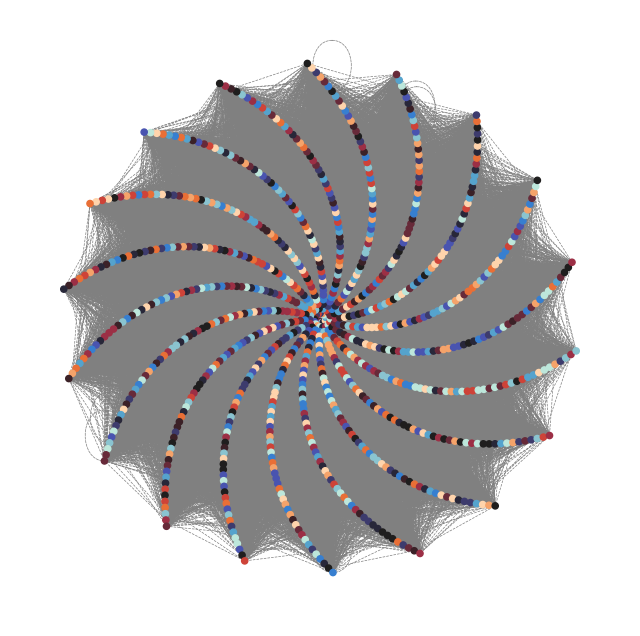

In [56]:
graph = nx.from_numpy_array(A.numpy())
cmap = sns.color_palette("icefire", as_cmap=True)
fig,ax = plt.subplots(figsize=(8,8))
nx.draw(graph, with_labels=False, node_color=community_labels.numpy(), cmap=cmap,pos=nx.spiral_layout(graph),node_size=20,edge_color='gray', width=0.5,style='dashed',ax=ax)
# fig.savefig("disbm_graph.pdf", dpi=300, bbox_inches='tight',pad_inches=0.)
fig.savefig("disbm_graph.png", dpi=300, bbox_inches='tight',pad_inches=0.)

In [57]:
epsilon = 1
W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)

In [58]:
X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform((W+W.t())/2.0)
X_low = torch.from_numpy(X_low).float()

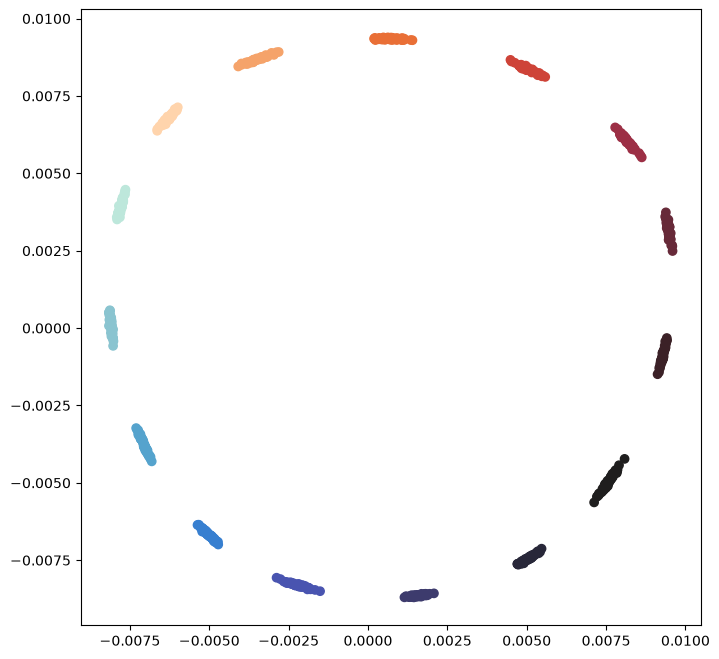

In [59]:
plt.figure(figsize=(8, 8))
plt.scatter(X_low[:,0].cpu().numpy(), X_low[:,1].cpu().numpy(), c=community_labels.cpu().numpy(), cmap=cmap)

In [60]:
results = randers_approximation(X_low,W, epsilon, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [61]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()
community_labels_plt = community_labels[idx].clone()

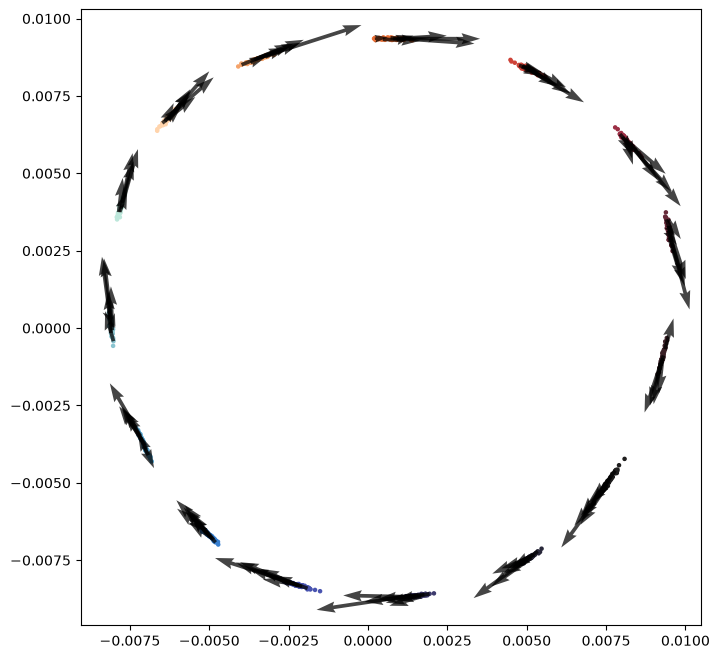

In [62]:
plt.figure(figsize=(8, 8))
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1], c=community_labels_plt, cmap=cmap,s=5
)
skip=10
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=0.3,
    angles="xy",
    scale_units="xy",
    alpha = results["admissible"][idx][::skip].float().sigmoid()
)

In [63]:
model, loss_list = interpolate_V(X_low, V, dim=m)

Loss: 0.0002:   0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.0000: 100%|██████████| 500/500 [00:00<00:00, 609.76it/s]


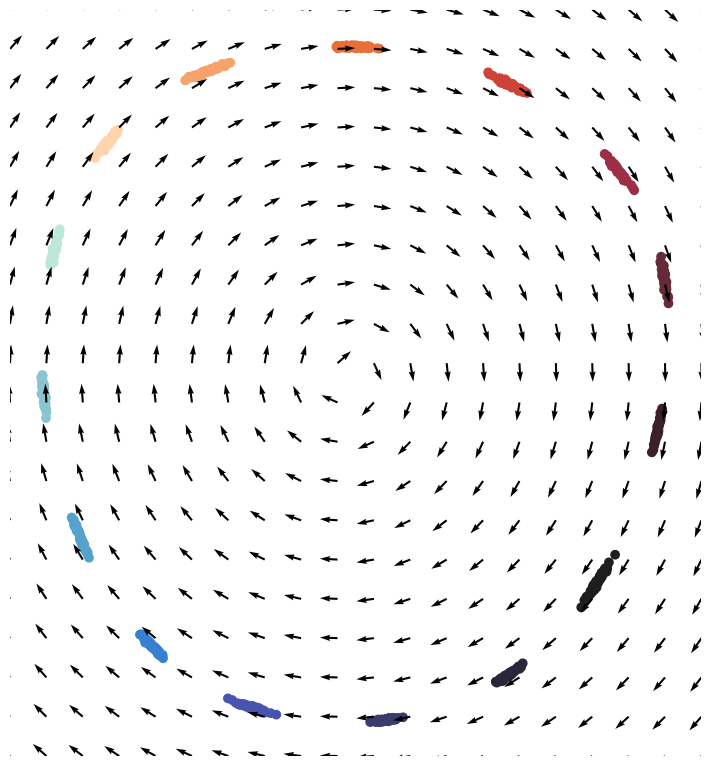

In [74]:
# Grid
bounds = get_bounds(X_low, margin=0.05)

x = torch.linspace(bounds[0], bounds[1], 20)
y = torch.linspace(bounds[2], bounds[3], 20)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
# grid_points += 1e-1 * torch.randn_like(grid_points)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=community_labels, cmap=cmap)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=2000,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
# plt.axis("equal")
plt.axis("off")
plt.savefig("disbm_vector_field.pdf", dpi=300, bbox_inches='tight',pad_inches=0.)
plt.show()